In [186]:
# Reload modules automatically
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [187]:
import cma
import numpy as np
from numbers import Real
import torch
from PIL import Image
import random
import requests
from io import BytesIO
import time
from matplotlib import cm
import matplotlib.pyplot as plt
from tqdm import tqdm
from os import path
import os
import json
from IPython.display import display, clear_output


# Utils imports
from utils.rasterize import *
from utils.load import get_segment_imgs, get_primitive_imgs
from utils.clipemb import CLIP_emb_from_IMG, CLIP_emb_from_TEXT, CLIP_emb_from_tensor
from utils.cma import clip_sol


DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

WIDTH = 300
HEIGHT = 300

CONTENT_DIR = './data'
RESULTS_DIR = path.join(CONTENT_DIR, 'results', 'grad')
SEGMENT_DIR = path.join(CONTENT_DIR, 'segment_img')
RW_PRIMITIVES_DIR = path.join(CONTENT_DIR, 'rw_primitives')
PRIMITIVE_DIR = path.join(CONTENT_DIR, 'primitives')

SEGMENT_IMGS = get_segment_imgs(SEGMENT_DIR, (WIDTH, HEIGHT))
RW_PRIMITIVES_IMGS = get_segment_imgs(RW_PRIMITIVES_DIR, (WIDTH, HEIGHT))
PRIMITIVE_IMGS = get_primitive_imgs(CONTENT_DIR, (WIDTH, HEIGHT))

In [ ]:
def loss_fn(x0, elem_list, prompt_embedding, return_sol=False):
    rasterized_img = differentiable_rasterize(elem_list, x0[:, :3], x0[:, 3], (WIDTH, HEIGHT)).to(DEVICE)

    # Mask of empty pixels
    mask = (rasterized_img[:, -1, :, :] == 0)
    mask_expanded = mask.unsqueeze(1).expand(-1, 3, -1, -1)

    # Set empty pixels to 1 (aka white)
    rasterized_img[:, :3, :, :][mask_expanded] = 1

    rasterized_emb = CLIP_emb_from_tensor(rasterized_img[:, :3, :, :])

    if return_sol:
        return rasterized_img, torch.nn.functional.cosine_similarity(rasterized_emb, prompt_embedding, dim=1)
    
    return torch.nn.functional.cosine_similarity(rasterized_emb, prompt_embedding, dim=1)

In [189]:
list(RW_PRIMITIVES_IMGS.items())[5:]

[('a cloudy night sky with a full moon',
  {'0sky': <PIL.Image.Image image mode=RGBA size=300x200>,
   '1moon': <PIL.Image.Image image mode=RGBA size=300x300>,
   '2cloud': <PIL.Image.Image image mode=RGBA size=300x129>}),
 ('a person on a hill',
  {'0landscape': <PIL.Image.Image image mode=RGBA size=300x200>,
   '1person': <PIL.Image.Image image mode=RGBA size=83x300>})]

In [ ]:
step = 1

for prompt_text, elems in list(RW_PRIMITIVES_IMGS.items())[0:]:
    elem_list = [torch.tensor(np.asarray(e), dtype=torch.float32, device=DEVICE) / 255 for e in list(elems.values())]
    prompt_embedding = CLIP_emb_from_TEXT(prompt_text).to(DEVICE)

    # Check if the directory exists
    if not path.exists(path.join(RESULTS_DIR, prompt_text)):
      os.makedirs(path.join(RESULTS_DIR, prompt_text))
    
    with open(path.join(RESULTS_DIR, prompt_text, 'results.json'), 'w') as f:
      pass # Open to reset the file


    x0 = torch.ones((len(elem_list), 4), dtype=torch.float, device=DEVICE) * 0.5
    x0[:, 3] = 0 # No rotation
    x0[1, 0:2] = 0.1 # Random position for second primitive
    x0.requires_grad_(True)

    # Create an optimizer, here using SGD.
    optimizer = torch.optim.AdamW([x0], lr=0.01)
    gamma = 0.2

    # Optimization loop: we will perform gradient ascent on the loss by
    # minimizing its negative.
    num_iters = 1000
    i = 0
    while i <= num_iters:
        i += 1
        x0_sigmoid = x0
        optimizer.zero_grad()
        rasterized_img, sim_loss = loss_fn(x0_sigmoid, elem_list=elem_list, prompt_embedding=prompt_embedding, return_sol=True)
        

        empty_pixel_loss = torch.sum(rasterized_img[:, -1, :, :] == 0) / (rasterized_img.shape[-1] * rasterized_img.shape[-2])

        # Cosine similarity loss + empty pixel count normalized
        loss = (1 - sim_loss) * (1 - gamma) + empty_pixel_loss * gamma

        # Save the results
        with open(path.join(RESULTS_DIR, prompt_text, 'results.json'), 'a') as f:
          json.dump({i: {
                          'full_loss': loss.item(),
                          'sim_loss': sim_loss.item(),
                          'pixel_loss': empty_pixel_loss.item(),
                        }
                    }, f)
          f.write('\n')

        loss.backward()
        optimizer.step()
        if i % step == 0:
            with torch.no_grad():
                rasterized_img = differentiable_rasterize(elem_list, x0_sigmoid[:, :3], x0_sigmoid[:, 3], (WIDTH, HEIGHT))
            
            # Mask of empty pixels
            mask = (rasterized_img[:, -1, :, :] == 0)
            mask_expanded = mask.unsqueeze(1).expand(-1, 3, -1, -1)

            # Set empty pixels to 1 (aka white)
            rasterized_img[:, :3, :, :][mask_expanded] = 1

            rasterized_img[:, -1, :, :] = 1  # Set alpha channel to 1

            rasterized_img = rasterized_img.detach().cpu().squeeze().permute(1, 2, 0).numpy()

            # Convert to PIL
            img_pil = Image.fromarray((rasterized_img * 255).astype(np.uint8))

            # Save rasterized image
            img_pil.save(path.join(RESULTS_DIR, prompt_text, f'epoch_{i}.png'))

            clear_output(wait=True)  # Clear previous output
            display(img_pil)
            print(f"Iteration {i}: Cosine Simliratity = {sim_loss.item():.4f} - Empty Pixel = {empty_pixel_loss.item():.4f}")


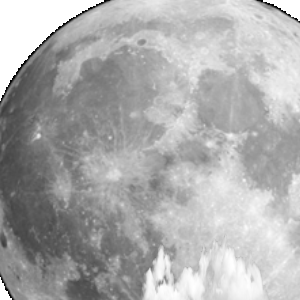

Iteration 1001: Cosine Simliratity = 0.2873 - Empty Pixel = 0.0509


In [ ]:
# No gamma

step = 1

for prompt_text, elems in list(RW_PRIMITIVES_IMGS.items())[0:]:
    elem_list = [torch.tensor(np.asarray(e), dtype=torch.float32, device=DEVICE) / 255 for e in list(elems.values())]
    prompt_embedding = CLIP_emb_from_TEXT(prompt_text).to(DEVICE)

    prompt_text = 'NOGAMMA_'+prompt_text
    
    # Check if the directory exists
    if not path.exists(path.join(RESULTS_DIR, prompt_text)):
      os.makedirs(path.join(RESULTS_DIR, prompt_text))
    
    with open(path.join(RESULTS_DIR, prompt_text, 'results.json'), 'w') as f:
      pass # Open to reset the file


    x0 = torch.ones((len(elem_list), 4), dtype=torch.float, device=DEVICE) * 0.5
    x0[:, 3] = 0 # No rotation
    x0[1, 0:2] = 0.1 # Random position for second primitive
    x0.requires_grad_(True)

    # Create an optimizer, here using SGD.
    optimizer = torch.optim.AdamW([x0], lr=0.01)
    gamma = 0

    # Optimization loop: we will perform gradient ascent on the loss by
    # minimizing its negative.
    num_iters = 1000
    i = 0
    while i <= num_iters:
        i += 1
        x0_sigmoid = x0
        optimizer.zero_grad()
        rasterized_img, sim_loss = loss_fn(x0_sigmoid, elem_list=elem_list, prompt_embedding=prompt_embedding, return_sol=True)
        

        empty_pixel_loss = torch.sum(rasterized_img[:, -1, :, :] == 0) / (rasterized_img.shape[-1] * rasterized_img.shape[-2])

        # Cosine similarity loss + empty pixel count normalized
        loss = (1 - sim_loss) * (1 - gamma) + empty_pixel_loss * gamma

        # Save the results
        with open(path.join(RESULTS_DIR, prompt_text, 'results.json'), 'a') as f:
          json.dump({i: {
                          'full_loss': loss.item(),
                          'sim_loss': sim_loss.item(),
                          'pixel_loss': empty_pixel_loss.item(),
                        }
                    }, f)
          f.write('\n')

        loss.backward()
        optimizer.step()
        if i % step == 0:
            with torch.no_grad():
                rasterized_img = differentiable_rasterize(elem_list, x0_sigmoid[:, :3], x0_sigmoid[:, 3], (WIDTH, HEIGHT))
            
            # Mask of empty pixels
            mask = (rasterized_img[:, -1, :, :] == 0)
            mask_expanded = mask.unsqueeze(1).expand(-1, 3, -1, -1)

            # Set empty pixels to 1 (aka white)
            rasterized_img[:, :3, :, :][mask_expanded] = 1

            rasterized_img[:, -1, :, :] = 1  # Set alpha channel to 1

            rasterized_img = rasterized_img.detach().cpu().squeeze().permute(1, 2, 0).numpy()

            # Convert to PIL
            img_pil = Image.fromarray((rasterized_img * 255).astype(np.uint8))

            # Save rasterized image
            img_pil.save(path.join(RESULTS_DIR, prompt_text, f'epoch_{i}.png'))

            clear_output(wait=True)  # Clear previous output
            display(img_pil)
            print(f"Iteration {i}: Cosine Simliratity = {sim_loss.item():.4f} - Empty Pixel = {empty_pixel_loss.item():.4f}")


In [191]:
def generate_nearby_xs(x0, n, epsilon=0.1):
    """
    Generates n values close to x0 within a range defined by epsilon.
    
    Parameters:
    x0 (float): The central value.
    n (int): Number of values to generate.
    epsilon (float): Maximum deviation from x0.
    
    Returns:
    numpy.ndarray: Array of n values close to x0.
    """
    return np.linspace(x0 - epsilon, x0 + epsilon, n)
    
def plot_loss_landscape(xs, loss_fn):
    """
    Plots the landscape of a given loss function.
    
    Parameters:
    xs (array-like): A list or array of input values.
    loss_fn (callable): A function that takes an input from xs and returns a loss value.
    """
    xs = np.array(xs)
    ys = np.array([loss_fn(torch.tensor(x)).item() for x in xs])
    
    xs = np.mean(xs.reshape(xs.shape[0], -1), axis=1)
    
    plt.figure(figsize=(8, 5))
    plt.plot(xs, ys, label='Loss Landscape', color='b')
    plt.xlabel('Input Values')
    plt.ylabel('Loss')
    plt.title('Loss Function Landscape')
    plt.legend()
    plt.grid(True)
    plt.show()

In [192]:
x0 = torch.ones((len(elem_list), 4)) * 0.5
x0[:, 0:1] = -1
x0[:, 2] = -1
x0[0, 3] = 0
x0[1, 3] = 22
x0[2, 3] = 0

x0 = x0.detach().cpu().numpy()
plot_loss_landscape(generate_nearby_xs(x0, 50), loss_fn)

IndexError: index 2 is out of bounds for dimension 0 with size 2